In [6]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set plotting style
%matplotlib inline
sns.set_style('whitegrid')

In [7]:

# Load dataset (using latin-1 to prevent errors with special characters in SMS)
df = pd.read_csv('spam.csv', encoding='latin-1')

# Keep only necessary columns and rename them
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Map labels to binary: ham = 0, spam = 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Display first 5 rows
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [8]:
def clean_text(text):
    text = str(text).lower()                   # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)       # Remove everything except letters and spaces
    text = re.sub(r'\s+', ' ', text).strip()   # Remove extra spaces
    return text

# Apply cleaning function to the message column
df['clean_message'] = df['message'].apply(clean_text)

# Show an example of original vs cleaned text
print("Original:", df['message'][2])
print("Cleaned: ", df['clean_message'][2])

Original: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned:  free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry questionstd txt ratetcs apply overs


In [9]:
# Initialize TF-IDF Vectorizer (limiting to 3000 most important words to save memory/time)
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')

# X contains the numerical vectors, y contains the target labels (0 or 1)
X = vectorizer.fit_transform(df['clean_message']).toarray()
y = df['label_num']

print(f"Shape of Feature Matrix (X): {X.shape}")
print(f"Shape of Target Vector (y): {y.shape}")

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining data size: {X_train.shape[0]}")
print(f"Testing data size: {X_test.shape[0]}")

Shape of Feature Matrix (X): (5572, 3000)
Shape of Target Vector (y): (5572,)

Training data size: 4457
Testing data size: 1115


In [10]:
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

# Train the model on the training data
rf_model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [11]:
# Predict on the test set
y_pred = rf_model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Detailed Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))

Model Accuracy: 97.58%

Classification Report:
              precision    recall  f1-score   support

     Ham (0)       0.97      1.00      0.99       965
    Spam (1)       1.00      0.82      0.90       150

    accuracy                           0.98      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115



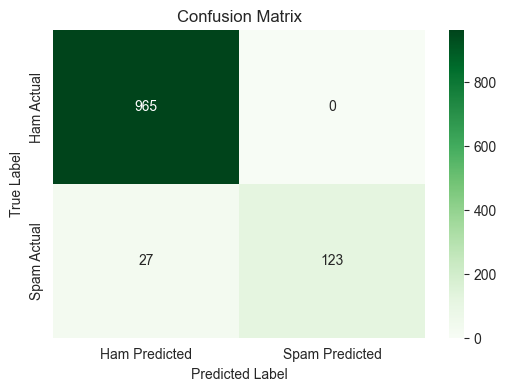

In [12]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Ham Predicted', 'Spam Predicted'], yticklabels=['Ham Actual', 'Spam Actual'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [19]:
def predict_spam(sms_text):
    # 1. Clean the input text
    cleaned_sms = clean_text(sms_text)
    # 2. Convert to numbers using the SAME vectorizer we trained on
    vectorized_sms = vectorizer.transform([cleaned_sms]).toarray()
    # 3. Predict
    prediction = rf_model.predict(vectorized_sms)[0]
    probability = rf_model.predict_proba(vectorized_sms)[0]
    
    label = "🚨 SPAM" if prediction == 1 else "✅ HAM"
    confidence = max(probability) * 100
    
    print(f"Message: '{sms_text}'")
    print(f"Prediction: {label} (Confidence: {confidence:.2f}%)\n")
    print("-" * 60)

# Test Cases
predict_spam("to reset your password, click the link below and follow the instructions.")
predict_spam("Hey, are you coming to the party tonight? Let me know.")
predict_spam("Win a FREE vacation to Dubai! Just enter your details: wintrip-now.com")
predict_spam("you just won a 1000 dollars! give me your bank details to claim")

Message: 'to reset your password, click the link below and follow the instructions.'
Prediction: ✅ HAM (Confidence: 66.00%)

------------------------------------------------------------
Message: 'Hey, are you coming to the party tonight? Let me know.'
Prediction: ✅ HAM (Confidence: 100.00%)

------------------------------------------------------------
Message: 'Win a FREE vacation to Dubai! Just enter your details: wintrip-now.com'
Prediction: ✅ HAM (Confidence: 54.00%)

------------------------------------------------------------
Message: 'you just won a 1000 dollars! give me your bank details to claim'
Prediction: 🚨 SPAM (Confidence: 81.00%)

------------------------------------------------------------
